In [764]:
#Install and import
!pip install yfinance hmmlearn pandas numpy matplotlib seaborn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Download the necessary data.

In [766]:
vix = yf.download("^VIX", start="2000-01-01", auto_adjust="True")
spy = yf.download("SPY", start="2000-01-01", auto_adjust="True")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Grab the necessary columns, clean, and calculate our log returns for SPY

In [768]:
spy_close = spy["Close"]
vix_close = vix["Close"].dropna()

log_returns = np.log(spy_close / spy_close.shift(1)).dropna()

## Data Overview

### SPY Log Returns (2000–Present)
- **Mean**: 0.0003 — small positive drift, reflects long-term upward trend
- **Std**: 0.012 — ~1.2% average daily volatility
- **Min**: -0.116 — worst single day crash (likely March 2020 or Oct 2008)
- **Max**: 0.136 — largest single day gain (likely post-crash recovery)

### VIX (2000–Present)
- **Mean**: 19.8 — historically anything below 20 is considered calm
- **Min**: 9.14 — extremely low fear, deep bull market conditions
- **Max**: 82.69 — COVID March 2020, peak panic
- **75th percentile**: 23.2 — 75% of days VIX was below 23, so above this is genuinely elevated fear

In [770]:
print(log_returns.describe())
print()
print(vix_close.describe())

Ticker          SPY
count   6587.000000
mean       0.000300
std        0.012193
min       -0.115887
25%       -0.004613
50%        0.000680
75%        0.005966
max        0.135577

Ticker         ^VIX
count   6588.000000
mean      19.832319
std        8.342085
min        9.140000
25%       14.010000
50%       17.790001
75%       23.202500
max       82.690002


## Plotting SPY & VIX Closing Prices

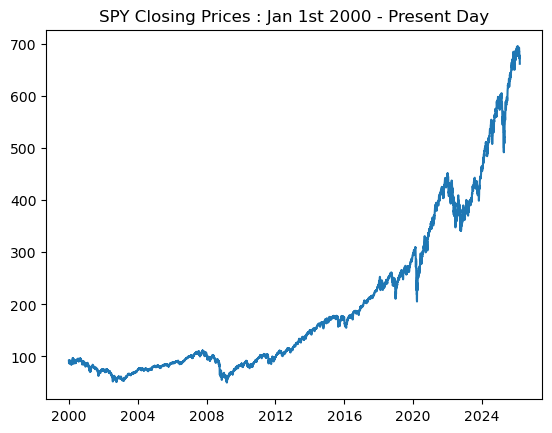

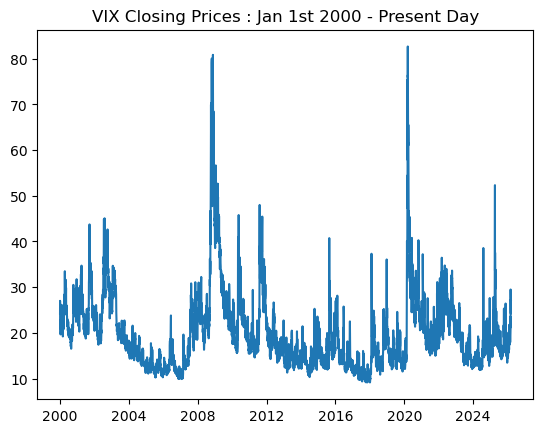

In [772]:
plt.plot(spy_close)
plt.title('SPY Closing Prices : Jan 1st 2000 - Present Day')
plt.show()

plt.plot(vix_close)
plt.title('VIX Closing Prices : Jan 1st 2000 - Present Day')
plt.show()

## Create / Clean the Data Frame

In [774]:
df = pd.concat([log_returns, vix_close], axis=1)
df_cleaned = df.dropna()
df_cleaned.shape

(6587, 2)

## Normalizing Values

Because the values of VIX are much higher than the ones in SPY, here we standardize the values to be centered around a mean of 0 and an std of 1

In [776]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)
print(df_scaled)

[[-3.29667685  0.86051577]
 [ 0.12198482  0.78858976]
 [-1.35356173  0.70707362]
 ...
 [-0.12765011  0.52725869]
 [-1.27970849  0.89408131]
 [-0.49021951  0.8820936 ]]


In [777]:
from hmmlearn import hmm
import collections

model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)

model.fit(df_scaled)
states = model.predict(df_scaled)

print(states)
print(collections.Counter(states))
print(model.means_)

[2 2 2 ... 2 2 2]
Counter({1: 2674, 0: 2423, 2: 1490})
[[ 0.04890205 -0.79454455]
 [-0.00176006 -0.06550099]
 [-0.07490138  1.38125151]]


<class 'numpy.ndarray'>
6587
DatetimeIndex(['2000-01-04', '2000-01-05', '2000-01-06'], dtype='datetime64[ns]', name='Date', freq=None)
(6587, 1)
['red', 'red', 'red', 'red', 'gray']


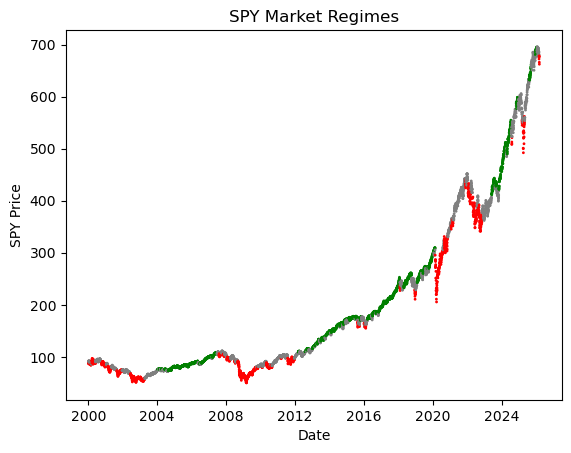

In [778]:
print(type(states))
print(len(states))
print(df_cleaned.index[:3])

spy_aligned = spy_close.loc[df_cleaned.index]
print(spy_aligned.shape)

colors = [{0: "green", 1: "gray", 2: "red"}[s] for s in states]
print(colors[:5])

plt.scatter(df_cleaned.index, spy_aligned, c=colors, s=1)
plt.title("SPY Market Regimes")
plt.xlabel("Date")
plt.ylabel("SPY Price")
plt.show()